In [5]:
import pandas as pd
import numpy as np
from dateutil import parser

Uploaded_data = pd.read_csv("data2.csv")
Uploaded_data = Uploaded_data.loc[:, ~Uploaded_data.columns.str.contains('^Unnamed')]

STANDARD_COLUMNS = ['eventID', 'scientificName', 'locality', 'temperature_C', 'DepthInMeters', 'decimalLatitude', 'decimalLongitude', 'sea_water_salinity', 'oxygen_concentration_mgL','sea_water_velocity', 'eventDate']

def normalize_column(col_name):

    norm = col_name.replace("_","").replace(" ","").replace("(","").replace(")","").lower()
    if norm.endswith('c'):
        norm = norm[:-1]
    return norm

col_map = {}
for std_col in STANDARD_COLUMNS:
    norm_std = normalize_column(std_col)
    for uploaded_col in Uploaded_data.columns:
        norm_uploaded = normalize_column(uploaded_col)
        if norm_std in norm_uploaded or norm_uploaded in norm_std:
            col_map[uploaded_col] = std_col

existing_cols = list(col_map.keys())
Standardized_format = Uploaded_data[existing_cols].copy()
Standardized_format.rename(columns=col_map, inplace=True)

Standardized_format = Standardized_format.loc[:, ~Standardized_format.columns.duplicated()]
if 'eventID' in Standardized_format.columns:
    Standardized_format['eventID'] = Standardized_format['eventID'].astype(str)
    pattern_eventID = r"^ATL\d{4}_\d{2}$"
    Standardized_format["eventID"] = Standardized_format["eventID"].where(Standardized_format["eventID"].str.match(pattern_eventID),np.nan)

if 'scientificName' in Standardized_format.columns:
    Standardized_format['scientificName'] = Standardized_format['scientificName'].astype(str)

if 'locality' in Standardized_format.columns:
    Standardized_format['locality'] = Standardized_format['locality'].astype(str)

if 'temperature_C' in Standardized_format.columns:
    Standardized_format['temperature_C'] = pd.to_numeric(Standardized_format["temperature_C"], errors="coerce")
    min_temp = -2
    max_temp = 40
    Standardized_format['temperature_C'] = Standardized_format['temperature_C'].where((Standardized_format['temperature_C'] >= min_temp) & (Standardized_format['temperature_C'] <= max_temp),np.nan)
    
if 'DepthInMeters' in Standardized_format.columns:
    Standardized_format['DepthInMeters'] = pd.to_numeric(Standardized_format["DepthInMeters"], errors="coerce")
    min_temp = 0
    max_temp = 11000
    Standardized_format['DepthInMeters'] = Standardized_format['DepthInMeters'].where((Standardized_format['DepthInMeters'] >= min_temp) & (Standardized_format['DepthInMeters'] <= max_temp),np.nan)

if 'decimalLatitude' in Standardized_format.columns:
    Standardized_format['decimalLatitude'] = pd.to_numeric(Standardized_format["decimalLatitude"], errors="coerce")

if 'decimalLongitude' in Standardized_format.columns:
    Standardized_format['decimalLongitude'] = pd.to_numeric(Standardized_format["decimalLongitude"], errors="coerce")

if 'sea_water_salinity' in Standardized_format.columns:
    Standardized_format['sea_water_salinity'] = pd.to_numeric(Standardized_format["sea_water_salinity"], errors="coerce")
    
if 'oxygen_concentration_mgL' in Standardized_format.columns:
    Standardized_format['oxygen_concentration_mgL'] = pd.to_numeric(Standardized_format["oxygen_concentration_mgL"], errors="coerce")

if 'sea_water_velocity' in Standardized_format.columns:
    Standardized_format['sea_water_velocity'] = pd.to_numeric(Standardized_format["sea_water_velocity"], errors="coerce")

if 'eventDate' in Standardized_format.columns:
    Standardized_format['eventDate'] = Standardized_format['eventDate'].apply(lambda x: parser.parse(str(x), fuzzy=True) if pd.notna(x) and str(x).strip().lower() not in ["nat", "nan", "none", ""] else pd.NaT)
    Standardized_format['eventDate'] = Standardized_format['eventDate'].dt.strftime('%Y-%m-%d')

Standard_taxonomy_col = ['eventID', 'taxonID', 'scientificName', 'vernacularName', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species', 'organismQuantity']

def normalize_column(col_name):
    norm = col_name.replace("_","").replace(" ","").replace("(","").replace(")","").lower()
    return norm

col_map = {}
for std_col in Standard_taxonomy_col:
    norm_std = normalize_column(std_col)
    for uploaded_col in Uploaded_data.columns:
        norm_uploaded = normalize_column(uploaded_col)
        if norm_std in norm_uploaded or norm_uploaded in norm_std:
            col_map[uploaded_col] = std_col

existing_cols = list(col_map.keys())
Standard_taxonomy_tab = Uploaded_data[existing_cols].copy()
Standard_taxonomy_tab.rename(columns=col_map, inplace=True)

Standard_taxonomy_tab = Standard_taxonomy_tab.drop_duplicates()

if 'eventID' in Standard_taxonomy_tab.columns:
    Standard_taxonomy_tab['eventID'] = Standard_taxonomy_tab['eventID'].astype(str)
    pattern_eventID = r"^SS\d{5}$"
    Standard_taxonomy_tab["eventID"] = Standard_taxonomy_tab["eventID"].where(Standard_taxonomy_tab["eventID"].str.match(pattern_eventID),np.nan)

if 'taxonID' in Standard_taxonomy_tab.columns:
    Standard_taxonomy_tab['taxonID'] = Standard_taxonomy_tab['taxonID'].astype(str)
    pattern_eventID = r"^EDNA_\d{3}$"
    Standard_taxonomy_tab["taxonID"] = Standard_taxonomy_tab["taxonID"].where(Standard_taxonomy_tab["taxonID"].str.match(pattern_eventID),np.nan)

if 'scientificName' in Standard_taxonomy_tab.columns:
    Standard_taxonomy_tab['scientificName'] = Standard_taxonomy_tab['scientificName'].astype(str)

if 'vernacularName' in Standard_taxonomy_tab.columns:
    Standard_taxonomy_tab['vernacularName'] = Standard_taxonomy_tab['vernacularName'].astype(str)

if 'Phylum' in Standard_taxonomy_tab.columns:
    Standard_taxonomy_tab['Phylum'] = Standard_taxonomy_tab['Phylum'].astype(str)

if 'Class' in Standard_taxonomy_tab.columns:
    Standard_taxonomy_tab['Class'] = Standard_taxonomy_tab['Class'].astype(str)
    
if 'Order' in Standard_taxonomy_tab.columns:
    Standard_taxonomy_tab['Order'] = Standard_taxonomy_tab['Order'].astype(str)
    
if 'Family' in Standard_taxonomy_tab.columns:
    Standard_taxonomy_tab['Family'] = Standard_taxonomy_tab['Family'].astype(str)
    
if 'Genus' in Standard_taxonomy_tab.columns:
    Standard_taxonomy_tab['Genus'] = Standard_taxonomy_tab['Genus'].astype(str)

if 'Species' in Standard_taxonomy_tab.columns:
    Standard_taxonomy_tab['Species'] = Standard_taxonomy_tab['Species'].astype(str)
    
if 'organismQuantity' in Standard_taxonomy_tab.columns:
    Standard_taxonomy_tab['organismQuantity'] = pd.to_numeric(Standard_taxonomy_tab["organismQuantity"], errors="coerce")

STANDARD_eDNA_COLUMNS = ['eventID', 'sampleID', 'scientificName', 'sequenceID', 'readCount', 'target_gene', 'relative_abundance', 'eventDate']

def normalize_column(col_name):
    norm = col_name.replace("_","").replace(" ","").replace("(","").replace(")","").lower()
    return norm

col_map = {}
for std_col in STANDARD_eDNA_COLUMNS:
    norm_std = normalize_column(std_col)
    for uploaded_col in Uploaded_data.columns:
        norm_uploaded = normalize_column(uploaded_col)
        if norm_std in norm_uploaded or norm_uploaded in norm_std:
            col_map[uploaded_col] = std_col

existing_cols = list(col_map.keys())
Standardized_eDNA = Uploaded_data[existing_cols].copy()
Standardized_eDNA.rename(columns=col_map, inplace=True)

Standardized_eDNA = Standardized_eDNA.drop_duplicates()

if 'eventID' in Standardized_eDNA.columns:
    Standardized_eDNA['eventID'] = Standardized_eDNA['eventID'].astype(str)
    pattern_eventID = r"^SS\d{5}$"
    Standardized_eDNA["eventID"] = Standardized_eDNA["eventID"].where(Standardized_eDNA["eventID"].str.match(pattern_eventID),np.nan)

if 'sampleID' in Standardized_eDNA.columns:
    Standardized_eDNA['sampleID'] = Standardized_eDNA['sampleID'].astype(str)
    pattern_eventID = r"^SAMP\d{4}$"
    Standardized_eDNA["sampleID"] = Standardized_eDNA["sampleID"].where(Standardized_eDNA["sampleID"].str.match(pattern_eventID),np.nan)

if 'scientificName' in Standardized_eDNA.columns:
    Standardized_eDNA['scientificName'] = Standardized_eDNA['scientificName'].astype(str)

if 'sequenceID' in Standardized_eDNA.columns:
    Standardized_eDNA['sequenceID'] = Standardized_eDNA['sequenceID'].astype(str)
    pattern_eventID = r"^SEQ_\d{4}_\d{4}$"
    Standardized_eDNA["sequenceID"] = Standardized_eDNA["sequenceID"].where(Standardized_eDNA["sequenceID"].str.match(pattern_eventID),np.nan)

if 'readCount' in Standardized_eDNA.columns:
    Standardized_eDNA['readCount'] = pd.to_numeric(Standardized_eDNA["readCount"], errors="coerce")
    min_readCount = 1000
    max_readCount = 25000
    Standardized_eDNA['readCount'] = Standardized_eDNA['readCount'].where((Standardized_eDNA['readCount'] >= min_readCount) & (Standardized_eDNA['readCount'] <= max_readCount),np.nan)

if 'target_gene' in Standardized_eDNA.columns:
    Standardized_eDNA['target_gene'] = Standardized_eDNA['target_gene'].astype(str)

if 'relative_abundance' in Standardized_eDNA.columns:
    Standardized_eDNA['relative_abundance'] = pd.to_numeric(Standardized_eDNA["relative_abundance"], errors="coerce")
    min_relative_abundance = 0
    max_relative_abundance = 100
    Standardized_eDNA['relative_abundance'] = Standardized_eDNA['relative_abundance'].where((Standardized_eDNA['relative_abundance'] >= min_relative_abundance) & (Standardized_eDNA['relative_abundance'] <= max_relative_abundance),np.nan)

if 'eventDate' in Standardized_format.columns:
    Standardized_format['eventDate'] = Standardized_format['eventDate'].apply(lambda x: parser.parse(str(x), fuzzy=True) if pd.notna(x) and str(x).strip().lower() not in ["nat", "nan", "none", ""] else pd.NaT)
    Standardized_format['eventDate'] = Standardized_format['eventDate'].dt.strftime('%Y-%m-%d')

Standard_otolith_col = ['Otolith_ID', 'eventID', 'scientificName', 'associatedMedia', 'otolith_length_mm', 'otolith_width_mm', 'Circularity', 'AspectRatio']

def normalize_column(col_name):
    norm = col_name.replace("_","").replace(" ","").replace("(","").replace(")","").lower()
    return norm

col_map = {}
for std_col in Standard_otolith_col:
    norm_std = normalize_column(std_col)
    for uploaded_col in Uploaded_data.columns:
        norm_uploaded = normalize_column(uploaded_col)
        if norm_std in norm_uploaded or norm_uploaded in norm_std:
            col_map[uploaded_col] = std_col

existing_cols = list(col_map.keys())
Standard_otolith_tab = Uploaded_data[existing_cols].copy()
Standard_otolith_tab.rename(columns=col_map, inplace=True)

Standard_otolith_tab = Standard_otolith_tab.drop_duplicates()

if 'Otolith_ID' in Standard_otolith_tab.columns:
    Standard_otolith_tab['Otolith_ID'] = Standard_otolith_tab['Otolith_ID'].astype(str)
    pattern_eventID = r"^CMLRE/OTL/\d{5}$"
    Standard_otolith_tab["Otolith_ID"] = Standard_otolith_tab["Otolith_ID"].where(Standard_otolith_tab["Otolith_ID"].str.match(pattern_eventID),np.nan)

if 'eventID' in Standard_otolith_tab.columns:
    Standard_otolith_tab['eventID'] = Standard_otolith_tab['eventID'].astype(str)
    pattern_eventID = r"^OTL_STN\d{3}_\d{2}$"
    Standard_otolith_tab["eventID"] = Standard_otolith_tab["eventID"].where(Standard_otolith_tab["eventID"].str.match(pattern_eventID),np.nan)

if 'scientificName' in Standard_otolith_tab.columns:
    Standard_otolith_tab['scientificName'] = Standard_otolith_tab['scientificName'].astype(str)

if 'associatedMedia' in Standard_otolith_tab.columns:
    Standard_otolith_tab['associatedMedia'] = Standard_otolith_tab['associatedMedia'].astype(str) 

if 'otolith_length_mm' in Standard_otolith_tab.columns:
    Standard_otolith_tab['otolith_length_mm'] = pd.to_numeric(Standard_otolith_tab["otolith_length_mm"], errors="coerce")
    min_otolith_length_mm = 0.006
    max_otolith_length_mm = 25
    Standard_otolith_tab['otolith_length_mm'] = Standard_otolith_tab['otolith_length_mm'].where((Standard_otolith_tab['otolith_length_mm'] >= min_otolith_length_mm) & (Standard_otolith_tab['otolith_length_mm'] <= max_otolith_length_mm),np.nan)

if 'otolith_width_mm' in Standard_otolith_tab.columns:
    Standard_otolith_tab['otolith_width_mm'] = pd.to_numeric(Standard_otolith_tab["otolith_width_mm"], errors="coerce")
    min_otolith_length_mm = 0.006
    max_otolith_length_mm = 25
    Standard_otolith_tab['otolith_width_mm'] = Standard_otolith_tab['otolith_width_mm'].where((Standard_otolith_tab['otolith_width_mm'] >= min_otolith_length_mm) & (Standard_otolith_tab['otolith_width_mm'] <= max_otolith_length_mm),np.nan)

if 'Circularity' in Standard_otolith_tab.columns:
    Standard_otolith_tab['Circularity'] = pd.to_numeric(Standard_otolith_tab["Circularity"], errors="coerce")
    min_otolith_length_mm = 0.006
    max_otolith_length_mm = 25
    Standard_otolith_tab['Circularity'] = Standard_otolith_tab['Circularity'].where((Standard_otolith_tab['Circularity'] >= min_otolith_length_mm) & (Standard_otolith_tab['Circularity'] <= max_otolith_length_mm),np.nan)

if 'AspectRatio' in Standard_otolith_tab.columns:
    Standard_otolith_tab['AspectRatio'] = pd.to_numeric(Standard_otolith_tab["AspectRatio"], errors="coerce")
    min_otolith_length_mm = 0.006
    max_otolith_length_mm = 25
    Standard_otolith_tab['AspectRatio'] = Standard_otolith_tab['AspectRatio'].where((Standard_otolith_tab['AspectRatio'] >= min_otolith_length_mm) & (Standard_otolith_tab['AspectRatio'] <= max_otolith_length_mm),np.nan)

Standardized_format = Standardized_format.loc[:, ~Standardized_format.columns.duplicated()]
Standard_taxonomy_tab = Standard_taxonomy_tab.loc[:, ~Standard_taxonomy_tab.columns.duplicated()]
Standardized_eDNA = Standardized_eDNA.loc[:, ~Standardized_eDNA.columns.duplicated()]
Standard_otolith_tab = Standard_otolith_tab.loc[:, ~Standard_otolith_tab.columns.duplicated()]

Ultimate_Dataset = pd.concat([
    Standardized_format.reindex(columns=['eventID','scientificName','locality','temperature_C','DepthInMeters','decimalLatitude','decimalLongitude','sea_water_salinity','oxygen_concentration_mgL','sea_water_velocity','eventDate'], fill_value=np.nan), 
    Standard_taxonomy_tab.reindex(columns=['eventID','taxonID','scientificName','vernacularName','Phylum','Class','Order','Family','Genus','Species','organismQuantity'], fill_value=np.nan), 
    Standardized_eDNA.reindex(columns=['eventID','sampleID','scientificName','sequenceID','readCount','target_gene','relative_abundance','eventDate'], fill_value=np.nan), 
    Standard_otolith_tab.reindex(columns=['Otolith_ID','eventID','scientificName','associatedMedia','otolith_length_mm','otolith_width_mm','Circularity','AspectRatio'], fill_value=np.nan)
], axis=1)

print("Select the dataset by entering the corresponding number:")
print("1: Ultimate Dataset")
print("2: Standardized Format")
print("3: Taxonomy")
print("4: eDNA")
print("5: Otolith")

choice = int(input("Enter your choice (1-5): "))

if choice == 1:
    selected_data = Ultimate_Dataset
    print("You selected: Ultimate Dataset")

elif choice == 2:
    selected_data = Standardized_format
    print("You selected: Standardized Format")

elif choice == 3:
    selected_data = Standard_taxonomy_tab
    print("You selected: Taxonomy")

elif choice == 4:
    selected_data = Standardized_eDNA
    print("You selected: eDNA")

elif choice == 5:
    selected_data = Standard_otolith_tab
    print("You selected: Otolith")

else:
    selected_data = None
    print("Invalid choice! Please enter a number from 1 to 5.")

selected_data


Select the dataset by entering the corresponding number:
1: Ultimate Dataset
2: Standardized Format
3: Taxonomy
4: eDNA
5: Otolith


Enter your choice (1-5):  1


You selected: Ultimate Dataset


,eventID,scientificName,locality,temperature_C,DepthInMeters,decimalLatitude,decimalLongitude,sea_water_salinity,oxygen_concentration_mgL,sea_water_velocity,...,relative_abundance,eventDate,Otolith_ID,eventID,scientificName,associatedMedia,otolith_length_mm,otolith_width_mm,Circularity,AspectRatio
0,NaN,Harpiliopsis depressa,"Agatti Island, Lakshadweep",15.27,10.0,10.860,72.18,36.47,7.07,1.76,...,NaN,24-03-2023,NaN,NaN,Harpiliopsis depressa,NaN,NaN,NaN,NaN,NaN
1,NaN,Saron marmoratus,"Agatti Island, Lakshadweep",13.68,10.0,10.860,72.18,35.02,2.69,2.65,...,NaN,13-07-2023,NaN,NaN,Saron marmoratus,NaN,NaN,NaN,NaN,NaN
2,NaN,Coralliocaris superba,"Agatti Island, Lakshadweep",7.40,10.0,10.860,72.18,32.42,6.92,0.85,...,NaN,14-11-2016,NaN,NaN,Coralliocaris superba,NaN,NaN,NaN,NaN,NaN
3,NaN,Coralliocaris superba,"Agatti Island, Lakshadweep",27.08,10.0,10.860,72.18,36.01,7.93,0.02,...,NaN,22-07-2021,NaN,NaN,Coralliocaris superba,NaN,NaN,NaN,NaN,NaN
4,NaN,Ophiomastix elegans,"Agatti, Lakshadweep",25.73,24.0,10.861,72.21,35.42,6.35,2.56,...,NaN,30-11-2015,NaN,NaN,Ophiomastix elegans,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,NaN,Munida andamanica,"Southwest off Trivandrum, Kerala",14.32,31.0,8.280,76.52,33.04,4.82,0.85,...,NaN,2017-Oct-26,NaN,NaN,Munida andamanica,NaN,NaN,NaN,NaN,NaN
330,NaN,Munidopsis wardeni,"Northwest off Dabhol, Maharashtra",10.94,263.0,17.620,72.01,33.22,3.40,0.47,...,NaN,2018-Jan-15,NaN,NaN,Munidopsis wardeni,NaN,NaN,NaN,NaN,NaN
331,NaN,Munidopsis stylirostris,"Southwest off Colachel, Tamil Nadu",5.65,635.0,8.010,76.43,36.71,5.21,1.23,...,NaN,2013-Dec-10,NaN,NaN,Munidopsis stylirostris,NaN,NaN,NaN,NaN,NaN
332,NaN,Munidopsis stylirostris,"Southwest off Colachel, Tamil Nadu",29.85,635.0,8.010,76.43,36.47,4.09,2.90,...,NaN,2013-Dec-10,NaN,NaN,Munidopsis stylirostris,NaN,NaN,NaN,NaN,NaN


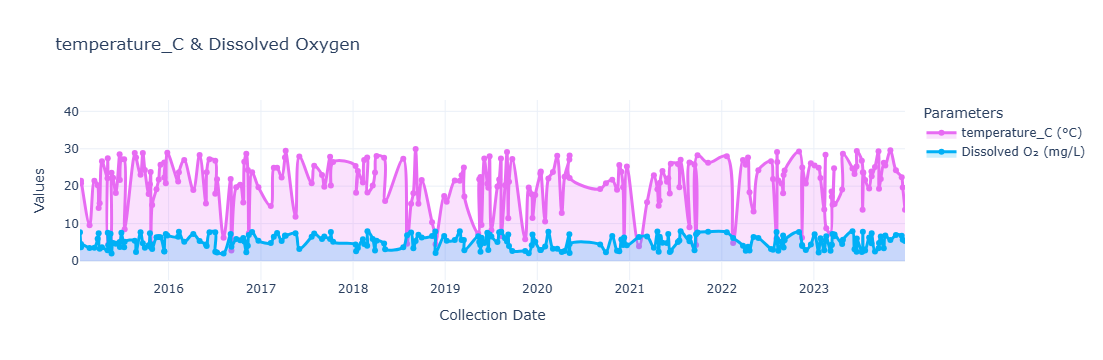

In [41]:
import plotly.graph_objects as go

Standardized_format['eventDate'] = pd.to_datetime(Standardized_format['eventDate'], format='%d-%m-%Y', errors='coerce')

clean_data = Standardized_format[(Standardized_format['temperature_C'] != '-') &(Standardized_format['oxygen_concentration_mgL'] != '-')].copy()

clean_data['temperature_C'] = pd.to_numeric(clean_data['temperature_C'], errors='coerce')
clean_data['oxygen_concentration_mgL'] = pd.to_numeric(clean_data['oxygen_concentration_mgL'], errors='coerce')

clean_data = clean_data.sort_values(by="eventDate", ascending=False).reset_index(drop=True)

top10_data = clean_data.head(334)

fig_Temp_and_O2 = go.Figure()

fig_Temp_and_O2.add_trace(go.Scatter(x=top10_data['eventDate'],y=top10_data['temperature_C'],mode='lines+markers',name='temperature_C (°C)',line=dict(color='rgba(231,107,243,1)', width=3, shape="spline"),marker=dict(size=6),fill='tozeroy',fillcolor='rgba(231,107,243,0.2)'))

fig_Temp_and_O2.add_trace(go.Scatter(x=top10_data['eventDate'],y=top10_data['oxygen_concentration_mgL'],mode='lines+markers',name='Dissolved O₂ (mg/L)',line=dict(color='rgba(0,176,246,1)', width=3, shape="spline"),marker=dict(size=6),fill='tozeroy',fillcolor='rgba(0,176,246,0.2)'))

fig_Temp_and_O2.update_layout(title="temperature_C & Dissolved Oxygen",xaxis_title="Collection Date",yaxis_title="Values",template="plotly_white",legend=dict(title="Parameters"))

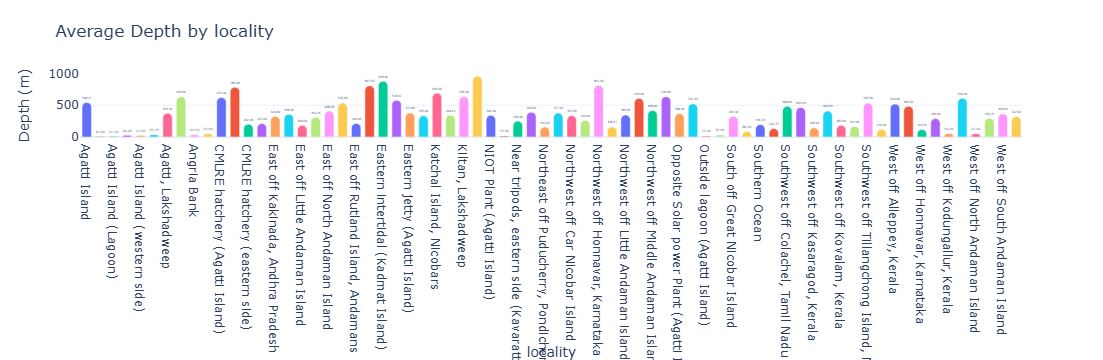

In [27]:
import plotly.express as px

clean_data = Standardized_format[Standardized_format['DepthInMeters'] != '-'].copy()

clean_data['DepthInMeters'] = pd.to_numeric(clean_data['DepthInMeters'], errors='coerce')

depth_data = clean_data.groupby('locality', as_index=False)['DepthInMeters'].mean()

fig_Depth = px.bar(depth_data,x='locality',y='DepthInMeters',color='locality',text='DepthInMeters',title="Average Depth by locality",labels={'DepthInMeters': 'Depth (m)', 'locality': 'Region'})

fig_Depth.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig_Depth.update_layout(xaxis_title="locality",yaxis_title="Depth (m)",template="plotly_white",showlegend=False,bargap=0.3)

try:
    fig_Depth.update_traces(marker=dict(cornerradius=12))
except:
    pass 

fig_Depth.update_layout(xaxis_title="locality",yaxis_title="Depth (m)",template="plotly_white",showlegend=False,bargap=0.3)

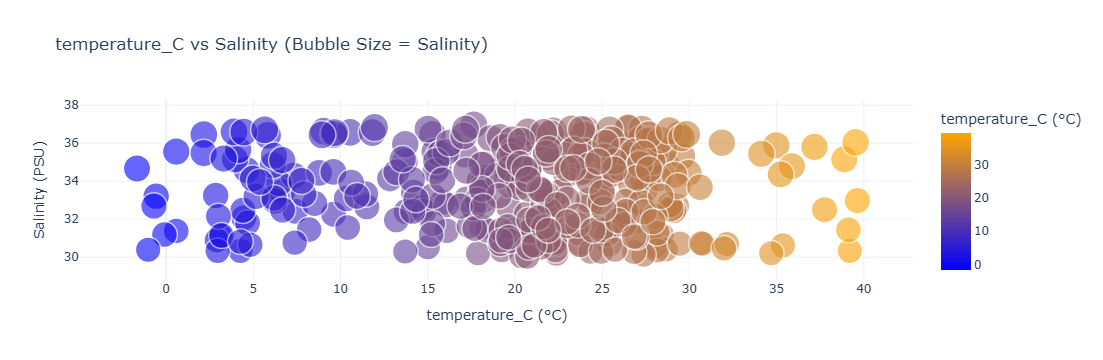

In [28]:
clean_data = Standardized_format[(Standardized_format['temperature_C'] != '-') &(Standardized_format['sea_water_salinity'] != '-')].copy()

clean_data['temperature_C'] = pd.to_numeric(clean_data['temperature_C'], errors='coerce')
clean_data['Salinity'] = pd.to_numeric(clean_data['sea_water_salinity'], errors='coerce')

clean_data = clean_data.dropna(subset=['temperature_C', 'Salinity'])

top30 = clean_data.head(334)

fig_Salinity = px.scatter(top30,x="temperature_C",y="Salinity",size="Salinity",color="temperature_C",color_continuous_scale=["blue", "orange"],opacity=0.6,title="temperature_C vs Salinity (Bubble Size = Salinity)",labels={"temperature_C": "temperature_C (°C)", "Salinity": "Salinity (PSU)"})

fig_Salinity.update_traces(marker=dict(line=dict(width=1.5, color=None)))

fig_Salinity.update_layout(template="plotly_white",coloraxis_colorbar=dict(title="temperature_C (°C)"))

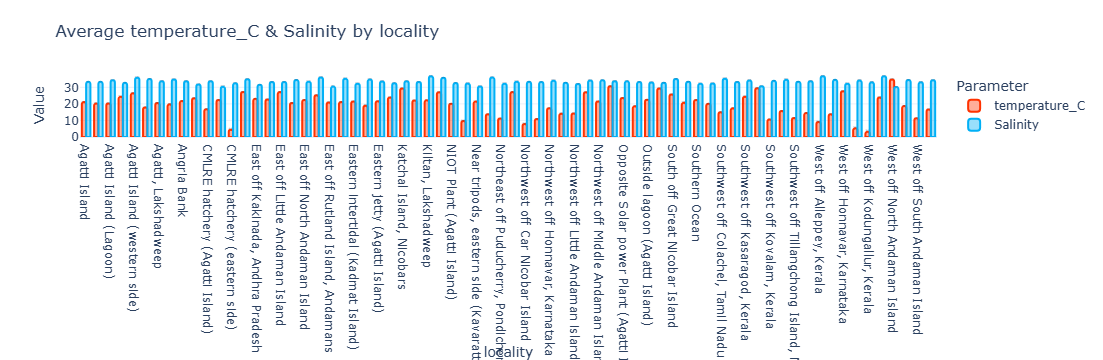

In [29]:
clean_data = Standardized_format[(Standardized_format['temperature_C'] != '-') &(Standardized_format['sea_water_salinity'] != '-') &(Standardized_format['locality'] != '-')].copy()

clean_data['temperature_C'] = pd.to_numeric(clean_data['temperature_C'], errors='coerce')
clean_data['Salinity'] = pd.to_numeric(clean_data['sea_water_salinity'], errors='coerce')

grouped = clean_data.groupby('locality', as_index=False)[['temperature_C', 'Salinity']].mean()

melted = grouped.melt(id_vars='locality', value_vars=['temperature_C', 'Salinity'],var_name='Parameter', value_name='Value')

fig_Temp_and_Salinity = px.bar(melted,x="locality",y="Value",color="Parameter",barmode="group",text="Value",title="Average temperature_C & Salinity by locality",labels={"Value": "Measurement", "locality": "Region"},color_discrete_map={"temperature_C": "rgba(255,50,0,0.4)","Salinity": "rgba(0,176,246,0.4)"})

fig_Temp_and_Salinity.update_traces(texttemplate='%{text:.2f}',textposition='outside',marker=dict(line=dict(width=2),cornerradius=5))

for trace in fig_Temp_and_Salinity.data:
    if trace.name == "temperature_C":
        trace.marker.line.color = "rgba(255,50,0,1)" 
    elif trace.name == "Salinity":
        trace.marker.line.color = "rgba(0,176,246,1)"
        
fig_Temp_and_Salinity.update_layout(template="plotly_white",xaxis_title="locality",yaxis_title="Value",bargap=0.3,legend_title="Parameter")

Select the visualization by entering the corresponding number:
1: temperature_C & DissolvedO2 By Date
2: Depth By locality
3: Salinity By temperature_C
4: temperature_C & Salinity By locality


Enter your choice (1-4):  1


You selected: temperature_C & DissolvedO2 By Date


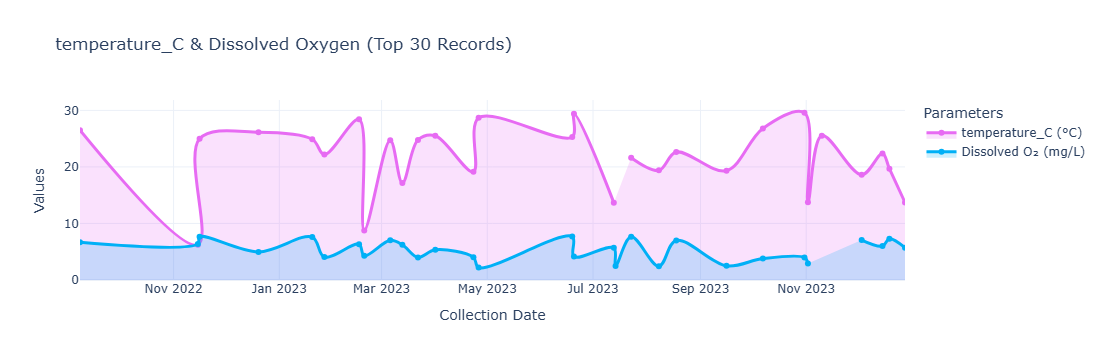

In [14]:
print("Select the visualization by entering the corresponding number:")
print("1: temperature_C & DissolvedO2 By Date")
print("2: Depth By locality")
print("3: Salinity By temperature_C")
print("4: temperature_C & Salinity By locality")

choice = int(input("Enter your choice (1-4): "))

if choice == 1:
    print("You selected: temperature_C & DissolvedO2 By Date")
    fig_Temp_and_O2.show()

elif choice == 2:
    print("You selected: Depth By locality")
    fig_Depth.show()

elif choice == 3:
    print("You selected: Salinity By temperature_C")
    fig_Salinity.show()

elif choice == 4:
    print("You selected: temperature_C & Salinity By locality")
    fig_Temp_and_Salinity.show()

else:
    print("Invalid choice! Please enter a number from 1 to 5.")